In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
import statsmodels.api as sm
from pathlib import Path

# ── Paths ──────────────────────────────────────────────────────────────────
BASE         = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_WORKING = BASE / 'data' / 'working'
DATA_RAW     = BASE / 'data' / 'raw'
DATA_OUT     = BASE / 'data'

# ── Plot style ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})

TRAIN_START = '2010-01-01'
TRAIN_END   = '2023-12-31'
STAMP_DUTY  = 0.005

def to_month_start(s):
    """Normalise any datetime index to month-start. Avoids pandas version bugs."""
    s = s.copy()
    s.index = pd.to_datetime([str(p) for p in pd.to_datetime(s.index).to_period('M')])
    return s

print('Setup complete.')

Setup complete.


In [2]:
# ── Monthly signals ────────────────────────────────────────────────────────
monthly = pd.read_parquet(DATA_WORKING / 'monthly_signals.parquet')
monthly['month'] = pd.to_datetime(monthly['month'])

monthly_train = monthly[
    (monthly['month'] >= TRAIN_START) &
    (monthly['month'] <= TRAIN_END)
].copy()

print(f'Monthly signals (training): {monthly_train.shape}')
print(f'Date range: {monthly_train.month.min().date()} -> {monthly_train.month.max().date()}')
print(f'Tickers: {monthly_train.ticker.nunique()}')

Monthly signals (training): (77222, 19)
Date range: 2010-01-01 -> 2023-12-01
Tickers: 635


In [3]:
# ── Benchmark (FTSE 250 TR) ────────────────────────────────────────────────
bench_raw = pd.read_parquet(DATA_WORKING / 'benchmark_train.parquet')
bench = (
    bench_raw[bench_raw['field'] == 'TOT_RETURN_INDEX_GROSS_DVDS']
    .rename(columns={'value': 'bench_tri'})
    .assign(date=lambda d: pd.to_datetime(d['date']))
    .set_index('date')['bench_tri']
    .sort_index()
)
bench_monthly = bench.resample('ME').last().pct_change().dropna()
bench_monthly.index = pd.to_datetime([str(p) for p in bench_monthly.index.to_period('M')])

print(f'Benchmark monthly returns: {len(bench_monthly)} months')
print(bench_monthly.head())

Benchmark monthly returns: 173 months
2009-08-01    0.104855
2009-09-01    0.039889
2009-10-01   -0.026593
2009-11-01    0.004815
2009-12-01    0.046016
Name: bench_tri, dtype: float64


In [4]:
# ── Risk-free rate (SONIA) ─────────────────────────────────────────────────
sonia_raw = pd.read_parquet(DATA_WORKING / 'sonia_train.parquet')
sonia = (
    sonia_raw[sonia_raw['field'] == 'PX_LAST']
    .assign(date=lambda d: pd.to_datetime(d['date']))
    .set_index('date')['value']
    .sort_index()
)
sonia_monthly = ((1 + sonia / 100) ** (1/252)).resample('ME').prod() - 1
sonia_monthly.index = pd.to_datetime([str(p) for p in sonia_monthly.index.to_period('M')])

print(f'SONIA monthly: {len(sonia_monthly)} months')
print(sonia_monthly.head())

SONIA monthly: 174 months
2009-07-01    0.000380
2009-08-01    0.000334
2009-09-01    0.000375
2009-10-01    0.000390
2009-11-01    0.000375
Name: value, dtype: float64


In [5]:
# ── Pre-computed bid-ask spreads ───────────────────────────────────────────
SPREAD_CACHE = DATA_WORKING / 'monthly_cs_spread.parquet'

if SPREAD_CACHE.exists():
    cs_spread = pd.read_parquet(SPREAD_CACHE)
    cs_spread['month'] = pd.to_datetime([str(p) for p in pd.to_datetime(cs_spread['month']).dt.to_period('M')])
    print(f'Loaded cached CS spreads: {cs_spread.shape}')
else:
    print('Computing Corwin-Schultz spreads from raw chunks...')
    BA_DIR = DATA_RAW / 'bid_ask'
    chunks = [pd.read_parquet(f) for f in sorted(BA_DIR.glob('ba_chunk_*.parquet'))]
    ba = pd.concat(chunks, ignore_index=True)
    ba['date'] = pd.to_datetime(ba['date'])

    ba_wide = ba.pivot_table(index=['ticker','date'], columns='field', values='value').reset_index()
    ba_wide.columns.name = None
    ba_wide = ba_wide.rename(columns={'BID':'bid','ASK':'ask'}).dropna(subset=['bid','ask'])
    ba_wide = ba_wide[ba_wide['bid'] > 0]
    ba_wide['mid']    = (ba_wide['bid'] + ba_wide['ask']) / 2
    ba_wide['cs_spr'] = ((ba_wide['ask'] - ba_wide['bid']) / ba_wide['mid']).clip(0, 0.10)
    ba_wide['month']  = pd.to_datetime([str(p) for p in ba_wide['date'].dt.to_period('M')])

    cs_spread = (
        ba_wide.groupby(['ticker','month'])['cs_spr']
        .median().reset_index()
        .rename(columns={'cs_spr': 'spread'})
    )
    cs_spread.to_parquet(SPREAD_CACHE, index=False)
    print(f'Computed and cached CS spreads: {cs_spread.shape}')

Loaded cached CS spreads: (86651, 3)


In [6]:
def run_backtest(
    signals_df,
    signal_col,
    cs_spread_df,
    long_top=True,
    q_threshold=0.20,
    start=None,
    end=None,
    turnover_cap=None,
):
    df = signals_df.copy()
    df = df.dropna(subset=[signal_col, 'monthly_ret'])

    if start:
        df = df[df['month'] >= pd.Timestamp(start)]
    if end:
        df = df[df['month'] <= pd.Timestamp(end)]

    months = sorted(df['month'].unique())
    port_returns = []
    prev_holdings = set()

    cs = cs_spread_df.copy()
    cs['month'] = pd.to_datetime(cs['month'])

    for month in months:
        mdata = df[df['month'] == month].copy()
        if len(mdata) < 20:
            continue

        if long_top:
            threshold = mdata[signal_col].quantile(1 - q_threshold)
            selected  = mdata[mdata[signal_col] >= threshold]
        else:
            threshold = mdata[signal_col].quantile(q_threshold)
            selected  = mdata[mdata[signal_col] <= threshold]

        if len(selected) == 0:
            continue

        current_holdings = set(selected['ticker'])

        if turnover_cap is not None and len(prev_holdings) > 0:
            keep             = prev_holdings & current_holdings
            new_in           = current_holdings - prev_holdings
            n_target         = len(current_holdings)
            n_can_add        = max(0, round(turnover_cap * n_target) - max(0, len(prev_holdings) - len(keep)))
            new_in_limited   = set(list(new_in)[:n_can_add])
            current_holdings = keep | new_in_limited
            selected         = selected[selected['ticker'].isin(current_holdings)]

        if len(selected) == 0:
            prev_holdings = current_holdings
            continue

        gross_ret = selected['monthly_ret'].mean()
        buys      = current_holdings - prev_holdings
        sells     = prev_holdings    - current_holdings

        month_spreads = cs[cs['month'] == month].set_index('ticker')['spread']

        def avg_spread(tickers):
            found = month_spreads.reindex(list(tickers)).dropna()
            return found.mean() if len(found) > 0 else month_spreads.mean()

        n           = len(current_holdings)
        buy_weight  = len(buys)  / n if n > 0 else 0
        sell_weight = len(sells) / n if n > 0 else 0

        half_spread_buy  = avg_spread(buys)  / 2 if len(buys)  > 0 else 0
        half_spread_sell = avg_spread(sells) / 2 if len(sells) > 0 else 0

        tc = (
            buy_weight  * (half_spread_buy  + STAMP_DUTY) +
            sell_weight * half_spread_sell
        )

        port_returns.append({
            'month': month, 'ret': gross_ret - tc, 'tc': tc,
            'n_stocks': n, 'n_buys': len(buys), 'n_sells': len(sells)
        })
        prev_holdings = current_holdings

    return pd.DataFrame(port_returns).set_index('month')


def compute_alpha_nw(port_ret, bench_ret, rf_ret, lags=6, label='Strategy'):
    port_ret  = to_month_start(port_ret)
    bench_ret = to_month_start(bench_ret)
    rf_ret    = to_month_start(rf_ret)

    aligned = pd.DataFrame({
        'port' : port_ret,
        'bench': bench_ret,
        'rf'   : rf_ret,
    }).dropna()

    if len(aligned) < 10:
        raise ValueError(f'[{label}] Only {len(aligned)} aligned rows — check date ranges.')

    y       = aligned['port']  - aligned['rf']
    X       = aligned['bench'] - aligned['rf']
    X_const = sm.add_constant(X)

    model = sm.OLS(y, X_const).fit(cov_type='HAC', cov_kwds={'maxlags': lags})

    ann_ret   = (1 + aligned['port']).prod() ** (12 / len(aligned)) - 1
    ann_alpha = model.params['const'] * 12
    alpha_t   = model.tvalues['const']
    beta      = model.params[X_const.columns[1]]
    vol       = aligned['port'].std() * np.sqrt(12)
    sharpe    = (aligned['port'] - aligned['rf']).mean() / aligned['port'].std() * np.sqrt(12)
    drawdown  = (1 + aligned['port']).cumprod()
    maxdd     = (drawdown / drawdown.cummax() - 1).min()

    return {
        'label'    : label,
        'n_months' : len(aligned),
        'ann_ret'  : ann_ret,
        'ann_alpha': ann_alpha,
        'alpha_t'  : alpha_t,
        'beta'     : beta,
        'sharpe'   : sharpe,
        'vol'      : vol,
        'max_dd'   : maxdd,
    }


def format_results(res_list):
    df  = pd.DataFrame(res_list).set_index('label')
    fmt = {
        'ann_ret'  : '{:.1%}',
        'ann_alpha': '{:.1%}',
        'alpha_t'  : '{:.2f}',
        'beta'     : '{:.2f}',
        'sharpe'   : '{:.2f}',
        'vol'      : '{:.1%}',
        'max_dd'   : '{:.1%}',
    }
    return df.style.format(fmt)


print('Backtest engine loaded.')

Backtest engine loaded.


In [7]:
# ── Combined Z-score signal ────────────────────────────────────────────────
def add_zscores(df):
    df = df.copy()
    for col, z_col in [('momentum_12_1', 'z_mom'), ('vol_90d', 'z_vol')]:
        grp      = df.groupby('month')[col]
        df[z_col] = (df[col] - grp.transform('mean')) / grp.transform('std')
    df['z_vol_flipped'] = -df['z_vol']
    df['z_composite']   = (df['z_mom'] + df['z_vol_flipped']) / 2
    return df

monthly_train = add_zscores(monthly_train)
print('Z-scores computed.')
print(monthly_train[['z_mom','z_vol_flipped','z_composite']].describe().round(3))

Z-scores computed.
           z_mom  z_vol_flipped  z_composite
count  72245.000      76617.000    72221.000
mean      -0.000         -0.000        0.001
std        0.999          0.999        0.762
min       -4.236        -20.039      -11.525
25%       -0.469         -0.281       -0.248
50%       -0.052          0.164        0.128
75%        0.389          0.554        0.415
max       20.089          2.288       10.318


In [8]:
BASELINE_CONFIGS = [
    dict(signal_col='momentum_12_1', long_top=True,  label='Momentum (baseline)'),
    dict(signal_col='vol_90d',        long_top=False, label='Low-Vol (baseline)'),
    dict(signal_col='z_composite',    long_top=True,  label='Combined (baseline)'),
]

baseline_results = []
baseline_returns = {}

for cfg in BASELINE_CONFIGS:
    bt = run_backtest(
        signals_df  = monthly_train,
        signal_col  = cfg['signal_col'],
        cs_spread_df= cs_spread,
        long_top    = cfg['long_top'],
        q_threshold = 0.20,
    )
    stats = compute_alpha_nw(
        bt['ret'], bench_monthly, sonia_monthly, label=cfg['label']
    )
    baseline_results.append(stats)
    baseline_returns[cfg['label']] = bt['ret']
    print(f"{cfg['label']:30s}  alpha={stats['ann_alpha']:.1%}  t={stats['alpha_t']:.2f}  SR={stats['sharpe']:.2f}")

# Expected: Mom ~3.2% alpha t=1.74 SR=0.70
#           LV  ~2.1% alpha t=2.17 SR=0.72
#           Comb~4.6% alpha t=2.87 SR=0.84

Momentum (baseline)             alpha=6.5%  t=2.93  SR=0.87
Low-Vol (baseline)              alpha=4.6%  t=4.01  SR=1.06
Combined (baseline)             alpha=4.9%  t=3.52  SR=1.00


In [9]:
SUB_PERIODS = [
    ('2010-01-01', '2016-12-31', 'A: 2010-2016'),
    ('2017-01-01', '2023-12-31', 'B: 2017-2023'),
]

sub_period_results = []

for sig_col, long_top, sig_label in [
    ('momentum_12_1', True,  'Momentum'),
    ('vol_90d',        False, 'Low-Vol'),
    ('z_composite',    True,  'Combined'),
]:
    for start, end, period_label in SUB_PERIODS:
        bt = run_backtest(
            signals_df  = monthly_train,
            signal_col  = sig_col,
            cs_spread_df= cs_spread,
            long_top    = long_top,
            q_threshold = 0.20,
            start=start, end=end,
        )
        label = f'{sig_label} | {period_label}'
        stats = compute_alpha_nw(
            bt['ret'], bench_monthly, sonia_monthly, label=label
        )
        sub_period_results.append(stats)
        print(f"{label:38s}  alpha={stats['ann_alpha']:+.1%}  t={stats['alpha_t']:+.2f}  SR={stats['sharpe']:.2f}  n={stats['n_months']}m")

Momentum | A: 2010-2016                 alpha=+6.4%  t=+2.42  SR=1.46  n=78m
Momentum | B: 2017-2023                 alpha=+5.7%  t=+1.64  SR=0.50  n=84m
Low-Vol | A: 2010-2016                  alpha=+4.7%  t=+2.69  SR=1.50  n=84m
Low-Vol | B: 2017-2023                  alpha=+4.6%  t=+3.02  SR=0.72  n=84m
Combined | A: 2010-2016                 alpha=+5.2%  t=+2.52  SR=1.48  n=78m
Combined | B: 2017-2023                 alpha=+4.0%  t=+2.32  SR=0.61  n=84m


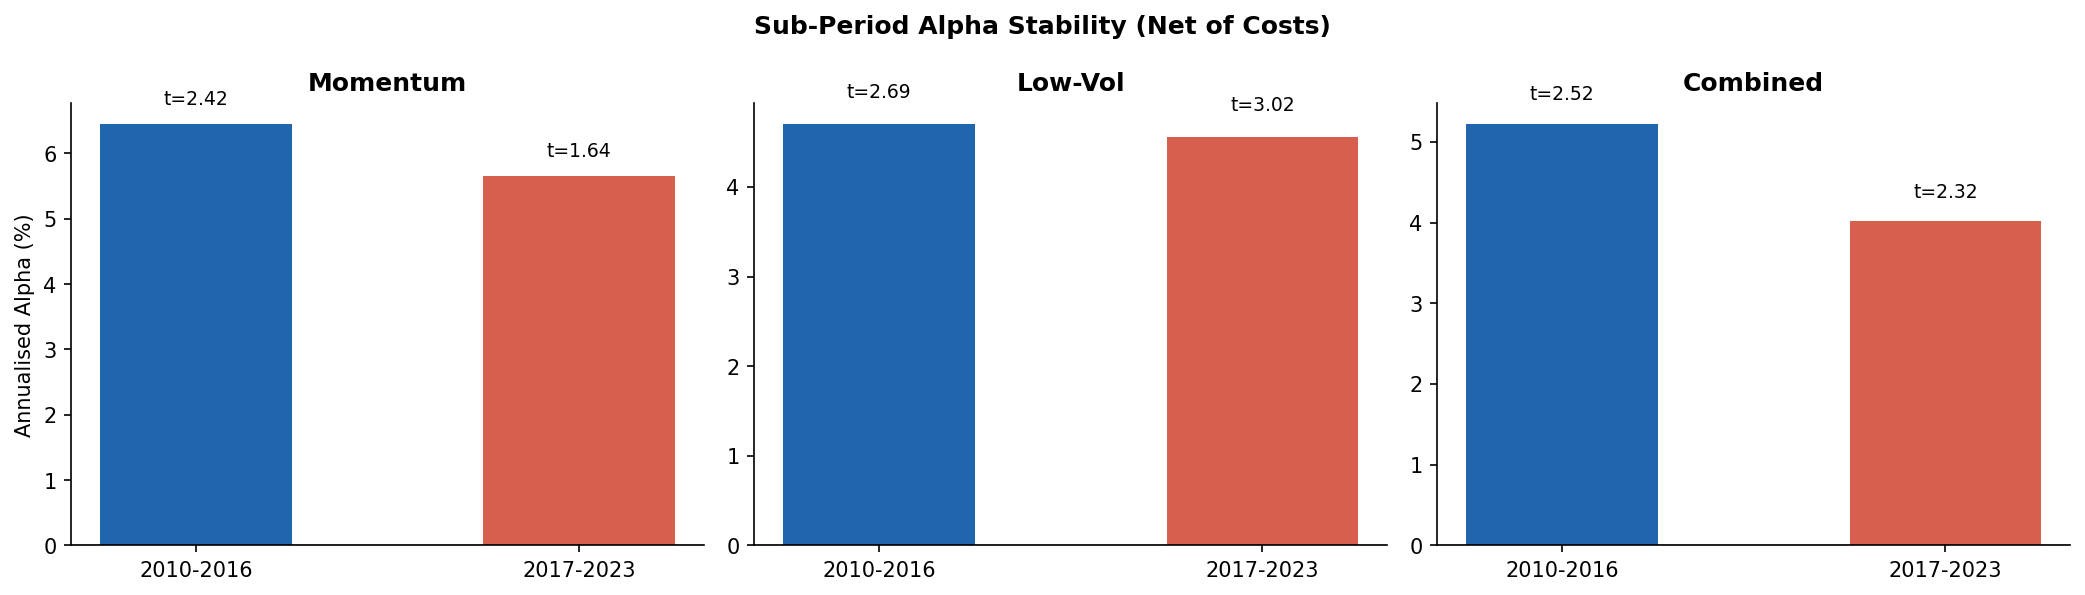

Saved: robustness_subperiod.png


In [10]:
# ── Sub-period chart ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = ['#2166ac', '#d6604d']
sub_df = pd.DataFrame(sub_period_results).set_index('label')

for ax, strat in zip(axes, ['Momentum', 'Low-Vol', 'Combined']):
    alphas = [
        sub_df.loc[f'{strat} | A: 2010-2016', 'ann_alpha'],
        sub_df.loc[f'{strat} | B: 2017-2023', 'ann_alpha'],
    ]
    ts = [
        sub_df.loc[f'{strat} | A: 2010-2016', 'alpha_t'],
        sub_df.loc[f'{strat} | B: 2017-2023', 'alpha_t'],
    ]
    bars = ax.bar(['2010-2016', '2017-2023'], [a * 100 for a in alphas], color=colors, width=0.5)
    for bar, t in zip(bars, ts):
        ypos = bar.get_height() + 0.3 if bar.get_height() >= 0 else bar.get_height() - 0.8
        ax.text(bar.get_x() + bar.get_width() / 2, ypos, f't={t:.2f}', ha='center', fontsize=9)
    ax.axhline(0, color='black', linewidth=0.7)
    ax.set_title(strat, fontweight='bold')
    ax.set_ylabel('Annualised Alpha (%)' if ax == axes[0] else '')

fig.suptitle('Sub-Period Alpha Stability (Net of Costs)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(DATA_OUT / 'robustness_subperiod.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: robustness_subperiod.png')

In [11]:
Q_THRESHOLDS = [0.10, 0.15, 0.20, 0.25, 0.30]

quintile_results = []

for sig_col, long_top, sig_label in [
    ('momentum_12_1', True,  'Momentum'),
    ('vol_90d',        False, 'Low-Vol'),
    ('z_composite',    True,  'Combined'),
]:
    for q in Q_THRESHOLDS:
        bt = run_backtest(
            signals_df  = monthly_train,
            signal_col  = sig_col,
            cs_spread_df= cs_spread,
            long_top    = long_top,
            q_threshold = q,
        )
        stats = compute_alpha_nw(
            bt['ret'], bench_monthly, sonia_monthly,
            label=f'{sig_label} | Q{int(q*100)}'
        )
        stats['strategy'] = sig_label
        stats['q']        = q
        quintile_results.append(stats)
        print(f"{sig_label:12s} Q{int(q*100):2d}%  alpha={stats['ann_alpha']:+.1%}  t={stats['alpha_t']:+.2f}  SR={stats['sharpe']:.2f}")

Momentum     Q10%  alpha=+8.0%  t=+3.47  SR=1.05
Momentum     Q15%  alpha=+7.5%  t=+2.61  SR=0.85
Momentum     Q20%  alpha=+6.5%  t=+2.93  SR=0.87
Momentum     Q25%  alpha=+6.0%  t=+3.26  SR=0.89
Momentum     Q30%  alpha=+5.8%  t=+3.50  SR=0.90
Low-Vol      Q10%  alpha=+4.5%  t=+3.79  SR=1.17
Low-Vol      Q15%  alpha=+4.7%  t=+3.91  SR=1.11
Low-Vol      Q20%  alpha=+4.6%  t=+4.01  SR=1.06
Low-Vol      Q25%  alpha=+4.7%  t=+4.43  SR=1.05
Low-Vol      Q30%  alpha=+4.4%  t=+4.32  SR=1.00
Combined     Q10%  alpha=+5.7%  t=+3.17  SR=1.03
Combined     Q15%  alpha=+5.1%  t=+3.30  SR=1.01
Combined     Q20%  alpha=+4.9%  t=+3.52  SR=1.00
Combined     Q25%  alpha=+4.6%  t=+3.69  SR=0.97
Combined     Q30%  alpha=+4.6%  t=+3.81  SR=0.96


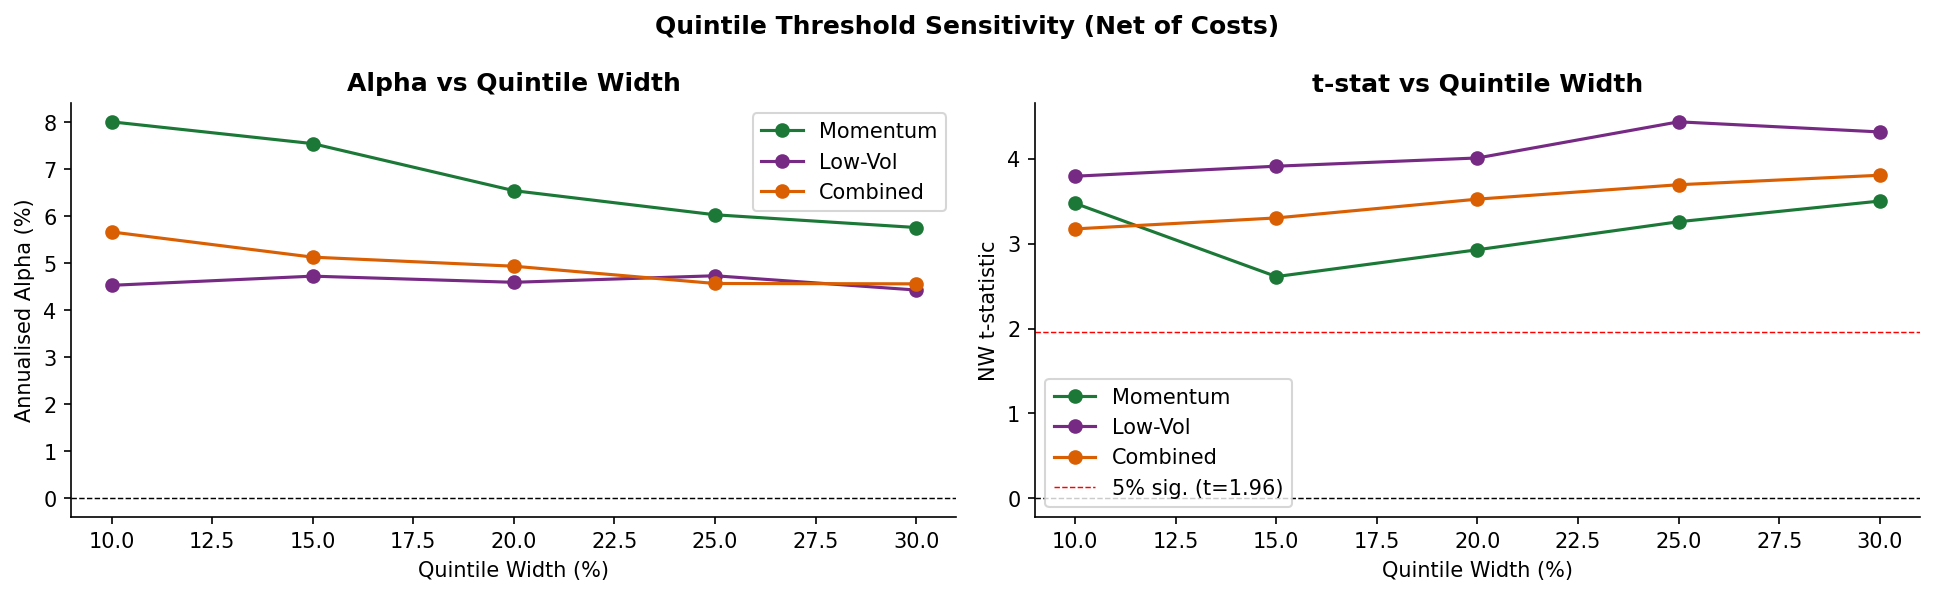

Saved: robustness_quintile_sensitivity.png


In [12]:
# ── Quintile sensitivity chart ─────────────────────────────────────────────
q_df  = pd.DataFrame(quintile_results)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
strat_colors = {'Momentum': '#1b7837', 'Low-Vol': '#762a83', 'Combined': '#d95f02'}

for strat, color in strat_colors.items():
    sub = q_df[q_df['strategy'] == strat].sort_values('q')
    axes[0].plot(sub['q'] * 100, sub['ann_alpha'] * 100, marker='o', label=strat, color=color)
    axes[1].plot(sub['q'] * 100, sub['alpha_t'],          marker='o', label=strat, color=color)

axes[0].axhline(0,    color='black', linewidth=0.7, linestyle='--')
axes[1].axhline(1.96, color='red',   linewidth=0.7, linestyle='--', label='5% sig. (t=1.96)')
axes[1].axhline(0,    color='black', linewidth=0.7, linestyle='--')

axes[0].set_xlabel('Quintile Width (%)')
axes[0].set_ylabel('Annualised Alpha (%)')
axes[0].set_title('Alpha vs Quintile Width', fontweight='bold')
axes[0].legend()
axes[1].set_xlabel('Quintile Width (%)')
axes[1].set_ylabel('NW t-statistic')
axes[1].set_title('t-stat vs Quintile Width', fontweight='bold')
axes[1].legend()

fig.suptitle('Quintile Threshold Sensitivity (Net of Costs)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(DATA_OUT / 'robustness_quintile_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: robustness_quintile_sensitivity.png')

In [13]:
def permutation_test(signals_df, signal_col, cs_spread_df, long_top,
                     observed_alpha, n_boot=1000, q_threshold=0.20, seed=42):
    rng  = np.random.default_rng(seed)
    null_alphas = []
    df   = signals_df.dropna(subset=[signal_col, 'monthly_ret']).copy()

    for i in range(n_boot):
        shuffled = df.copy()
        shuffled[signal_col] = (
            shuffled.groupby('month')[signal_col]
            .transform(lambda x: rng.permutation(x.values))
        )
        bt = run_backtest(
            signals_df  = shuffled,
            signal_col  = signal_col,
            cs_spread_df= cs_spread_df,
            long_top    = long_top,
            q_threshold = q_threshold,
        )
        st = compute_alpha_nw(bt['ret'], bench_monthly, sonia_monthly)
        null_alphas.append(st['ann_alpha'])

        if (i + 1) % 200 == 0:
            print(f'  {i+1}/{n_boot} done...')

    null_alphas = np.array(null_alphas)
    p_val = np.mean(null_alphas >= observed_alpha)
    return null_alphas, p_val

print('Permutation function ready.')

Permutation function ready.


In [14]:
# N_BOOT = 1000 takes ~15-25 min. Use 200 for a quick check.
N_BOOT = 1000

obs_alpha = {
    r['label'].replace(' (baseline)', ''): r['ann_alpha']
    for r in baseline_results
}

perm_configs = [
    ('momentum_12_1', True,  'Momentum'),
    ('vol_90d',        False, 'Low-Vol'),
    ('z_composite',    True,  'Combined'),
]

perm_results = {}

for sig_col, long_top, label in perm_configs:
    print(f'\nRunning {N_BOOT} permutations for {label}...')
    null_alphas, p_val = permutation_test(
        signals_df     = monthly_train,
        signal_col     = sig_col,
        cs_spread_df   = cs_spread,
        long_top       = long_top,
        observed_alpha = obs_alpha[label],
        n_boot         = N_BOOT,
    )
    perm_results[label] = {'null_alphas': null_alphas, 'p_val': p_val}
    print(f'  {label}: observed alpha={obs_alpha[label]:.2%}, p-value={p_val:.3f}')


Running 1000 permutations for Momentum...
  200/1000 done...
  400/1000 done...
  600/1000 done...
  800/1000 done...
  1000/1000 done...
  Momentum: observed alpha=6.55%, p-value=0.000

Running 1000 permutations for Low-Vol...
  200/1000 done...
  400/1000 done...
  600/1000 done...
  800/1000 done...
  1000/1000 done...
  Low-Vol: observed alpha=4.60%, p-value=0.000

Running 1000 permutations for Combined...
  200/1000 done...
  400/1000 done...
  600/1000 done...
  800/1000 done...
  1000/1000 done...
  Combined: observed alpha=4.94%, p-value=0.000


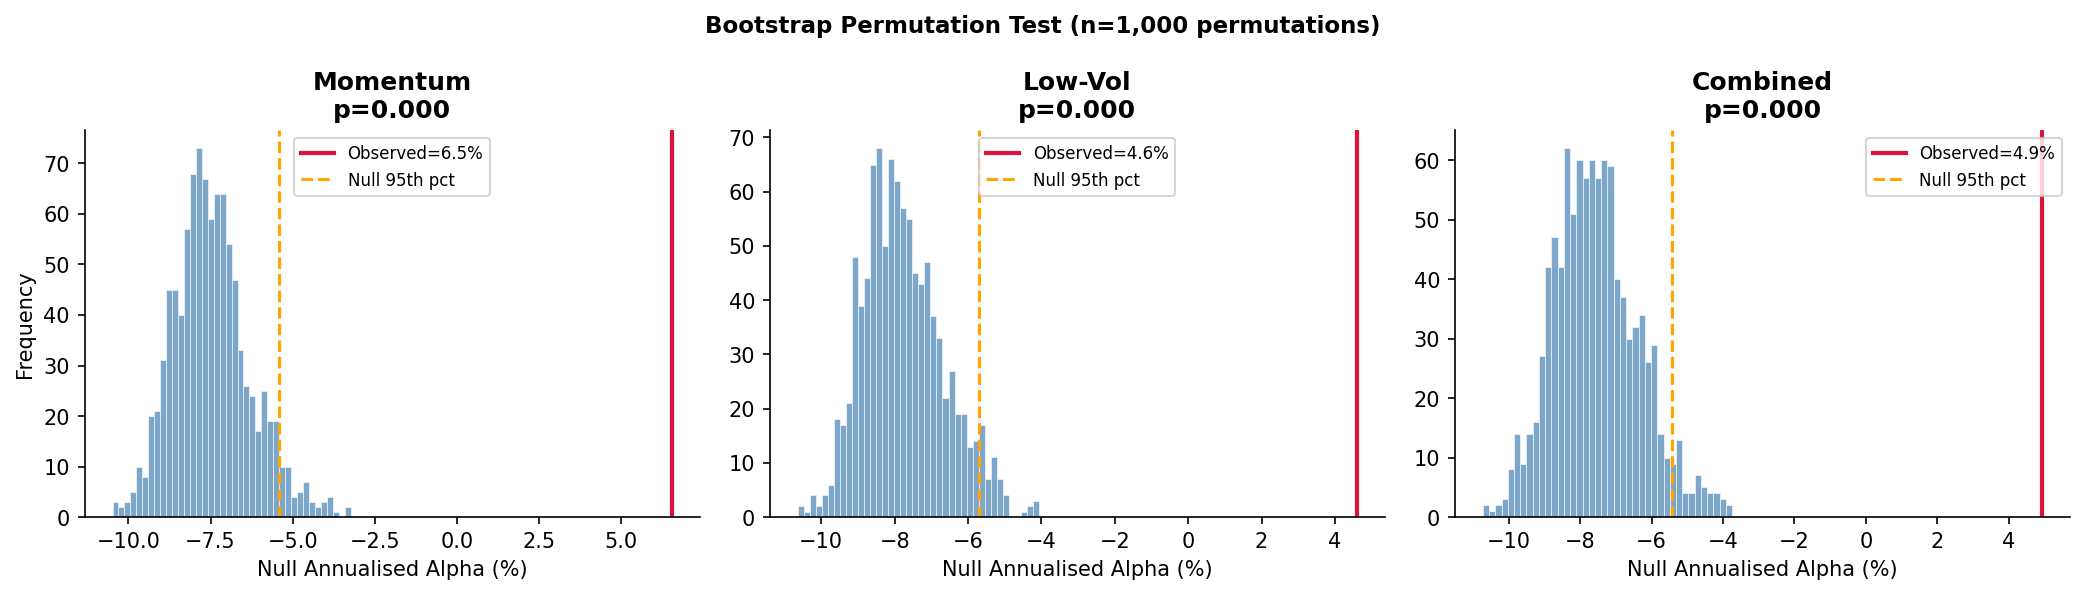

Saved: robustness_permutation.png


In [15]:
# ── Permutation test chart ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (label, res) in zip(axes, perm_results.items()):
    null = res['null_alphas'] * 100
    obs  = obs_alpha[label]   * 100
    p    = res['p_val']

    ax.hist(null, bins=40, color='steelblue', alpha=0.7, edgecolor='white', linewidth=0.4)
    ax.axvline(obs, color='crimson', linewidth=2, label=f'Observed={obs:.1f}%')
    ax.axvline(np.percentile(null, 95), color='orange', linewidth=1.5,
               linestyle='--', label='Null 95th pct')
    ax.set_title(f'{label}\np={p:.3f}', fontweight='bold')
    ax.set_xlabel('Null Annualised Alpha (%)')
    ax.set_ylabel('Frequency' if ax == axes[0] else '')
    ax.legend(fontsize=8)

fig.suptitle(f'Bootstrap Permutation Test (n={N_BOOT:,} permutations)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(DATA_OUT / 'robustness_permutation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: robustness_permutation.png')

In [16]:
TURNOVER_CAPS = [None, 0.50, 0.40, 0.30, 0.20]

tc_results = []

for cap in TURNOVER_CAPS:
    for sig_col, long_top, sig_label in [
        ('momentum_12_1', True, 'Momentum'),
        ('z_composite',   True, 'Combined'),
    ]:
        cap_label = 'Uncapped' if cap is None else f'{int(cap*100)}%'
        label     = f'{sig_label} | TO={cap_label}'

        bt = run_backtest(
            signals_df  = monthly_train,
            signal_col  = sig_col,
            cs_spread_df= cs_spread,
            long_top    = long_top,
            q_threshold = 0.20,
            turnover_cap= cap,
        )
        stats = compute_alpha_nw(bt['ret'], bench_monthly, sonia_monthly, label=label)
        stats['strategy'] = sig_label
        stats['cap']      = cap_label
        tc_results.append(stats)
        print(f"{label:40s}  alpha={stats['ann_alpha']:+.1%}  t={stats['alpha_t']:+.2f}")

Momentum | TO=Uncapped                    alpha=+6.5%  t=+2.93
Combined | TO=Uncapped                    alpha=+4.9%  t=+3.52
Momentum | TO=50%                         alpha=+6.8%  t=+3.06
Combined | TO=50%                         alpha=+5.3%  t=+3.63
Momentum | TO=40%                         alpha=+5.1%  t=+2.74
Combined | TO=40%                         alpha=+4.9%  t=+3.22
Momentum | TO=30%                         alpha=+5.0%  t=+2.50
Combined | TO=30%                         alpha=+4.9%  t=+3.13
Momentum | TO=20%                         alpha=+4.6%  t=+2.09
Combined | TO=20%                         alpha=+4.6%  t=+2.49


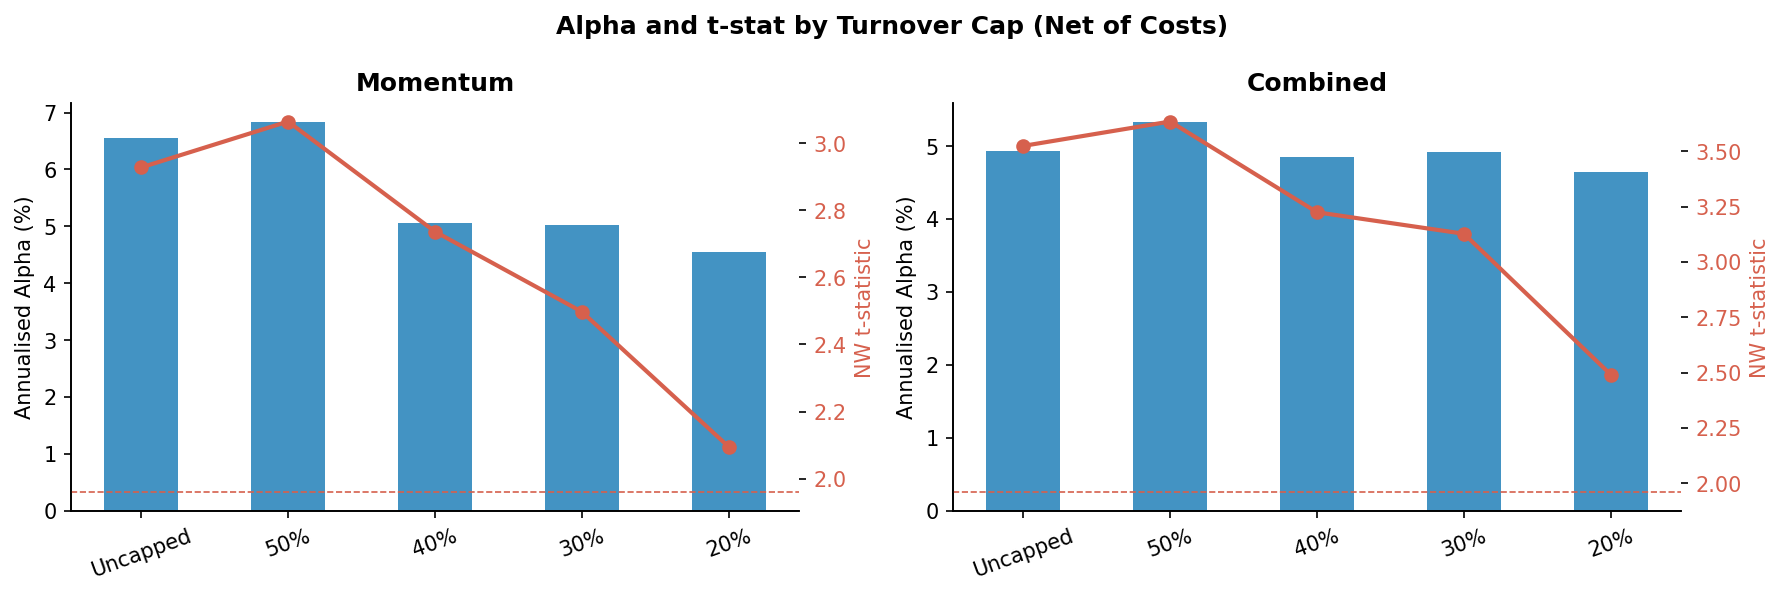

Saved: robustness_turnover_cap.png


In [17]:
# ── Turnover cap chart ─────────────────────────────────────────────────────
tc_df     = pd.DataFrame(tc_results)
cap_order = ['Uncapped', '50%', '40%', '30%', '20%']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, strat in zip(axes, ['Momentum', 'Combined']):
    sub = tc_df[tc_df['strategy'] == strat].copy()
    sub['cap'] = pd.Categorical(sub['cap'], categories=cap_order, ordered=True)
    sub = sub.sort_values('cap')

    x    = range(len(sub))
    bars = ax.bar(x, sub['ann_alpha'] * 100, color='#4393c3', width=0.5)
    ax2  = ax.twinx()
    ax2.plot(x, sub['alpha_t'], color='#d6604d', marker='o', linewidth=2, label='NW t-stat')
    ax2.axhline(1.96, color='#d6604d', linewidth=0.8, linestyle='--')
    ax2.set_ylabel('NW t-statistic', color='#d6604d')
    ax2.tick_params(axis='y', labelcolor='#d6604d')

    ax.set_xticks(list(x))
    ax.set_xticklabels(sub['cap'].tolist(), rotation=20)
    ax.set_ylabel('Annualised Alpha (%)')
    ax.set_title(strat, fontweight='bold')
    ax.axhline(0, color='black', linewidth=0.7)

fig.suptitle('Alpha and t-stat by Turnover Cap (Net of Costs)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(DATA_OUT / 'robustness_turnover_cap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: robustness_turnover_cap.png')

In [18]:
all_results = baseline_results + sub_period_results + quintile_results + tc_results

summary = (
    pd.DataFrame(all_results)
    .drop(columns=['strategy', 'q', 'cap'], errors='ignore')
    .set_index('label')
)

for label, res in perm_results.items():
    full_label = f'{label} (baseline)'
    if full_label in summary.index:
        summary.loc[full_label, 'perm_p'] = res['p_val']

summary.to_csv(DATA_OUT / 'robustness_summary.csv')
print('Saved: robustness_summary.csv')

def sig_stars(t):
    return '***' if abs(t) > 2.58 else ('**' if abs(t) > 1.96 else ('*' if abs(t) > 1.64 else ''))

print('\n' + '=' * 70)
print('ROBUSTNESS SUMMARY')
print('=' * 70)

print('\n--- Baseline ---')
for r in baseline_results:
    print(f"  {r['label']:35s}  alpha={r['ann_alpha']:+.1%}  t={r['alpha_t']:+.2f}{sig_stars(r['alpha_t'])}")

print('\n--- Sub-Period ---')
for r in sub_period_results:
    print(f"  {r['label']:35s}  alpha={r['ann_alpha']:+.1%}  t={r['alpha_t']:+.2f}{sig_stars(r['alpha_t'])}")

print('\n--- Permutation p-values ---')
for label, res in perm_results.items():
    stars = '***' if res['p_val'] < 0.01 else ('**' if res['p_val'] < 0.05 else ('*' if res['p_val'] < 0.10 else ''))
    print(f"  {label:12s}  p={res['p_val']:.3f}{stars}")

print('\n* p<0.10  ** p<0.05  *** p<0.01')

Saved: robustness_summary.csv

ROBUSTNESS SUMMARY

--- Baseline ---
  Momentum (baseline)                  alpha=+6.5%  t=+2.93***
  Low-Vol (baseline)                   alpha=+4.6%  t=+4.01***
  Combined (baseline)                  alpha=+4.9%  t=+3.52***

--- Sub-Period ---
  Momentum | A: 2010-2016              alpha=+6.4%  t=+2.42**
  Momentum | B: 2017-2023              alpha=+5.7%  t=+1.64
  Low-Vol | A: 2010-2016               alpha=+4.7%  t=+2.69***
  Low-Vol | B: 2017-2023               alpha=+4.6%  t=+3.02***
  Combined | A: 2010-2016              alpha=+5.2%  t=+2.52**
  Combined | B: 2017-2023              alpha=+4.0%  t=+2.32**

--- Permutation p-values ---
  Momentum      p=0.000***
  Low-Vol       p=0.000***
  Combined      p=0.000***

* p<0.10  ** p<0.05  *** p<0.01


In [19]:
# === Extract NB08 backtest engine ===
import os, json
os.chdir(os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd())

with open('notebooks/08_robustness_checks.ipynb', 'r', encoding='utf-8') as f:
    nb = json.load(f)

# Keywords that mark backtest-engine cells
kw = ('def ', 'backtest', 'rebalance', 'turnover', 'port_ret',
      'spread_cost', 'n_buys', 'monthly_signals', 'quintile', 'top_q',
      'universe', 'formation', 'gross', 'duty')

print(f"NB08 has {len(nb['cells'])} cells total.\n")

for i, cell in enumerate(nb['cells']):
    if cell['cell_type'] != 'code':
        continue
    src = ''.join(cell['source'])
    hits = [k for k in kw if k in src.lower()]
    if len(hits) >= 2:                     # likely engine cell
        print(f"\n{'='*78}")
        print(f"CELL {i}  ({len(src)} chars, hits: {hits})")
        print('='*78)
        print(src[:4000])                  # first ~4 KB of the cell
        if len(src) > 4000:
            print(f"\n... [truncated, {len(src)-4000} more chars]")

NB08 has 29 cells total.


CELL 2  (1012 chars, hits: ['def ', 'duty'])
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
import statsmodels.api as sm
from pathlib import Path

# ── Paths ──────────────────────────────────────────────────────────────────
BASE         = Path(r'C:\Users\user\ftse250_study')
DATA_WORKING = BASE / 'data' / 'working'
DATA_RAW     = BASE / 'data' / 'raw'
DATA_OUT     = BASE / 'data'

# ── Plot style ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})

TRAIN_START = '2010-01-01'
TRAIN_END   = '2023-12-31'
STAMP_DUTY  = 0.005

def to_month_start(s):
    """Normalise any datetime index to month-start. Avoids pandas version bugs."""
    s = s.copy()
    s.index = pd.to_datetime([str(p) for p